In [572]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [484]:
df=pd.read_csv('customer.csv')
df.head()


,Unnamed: 0,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b
0,7,000006646_03,Male,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F
1,8,000007827_01,Female,NaN,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T
2,9,000008359_04,Female,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F
3,10,000008529_01,Female,NaN,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F
4,11,000008744_02,Male,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F


### Data Exploration

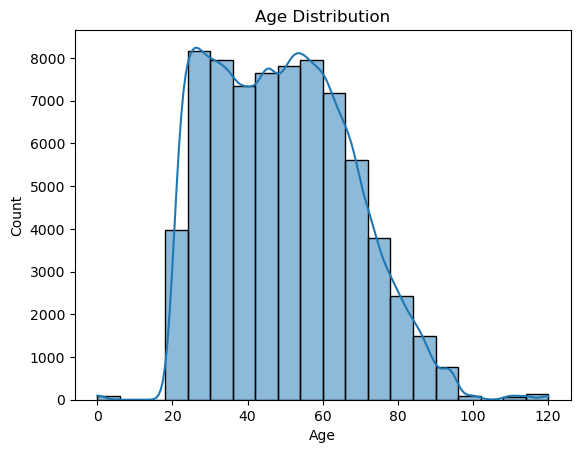

age_group
Middle-aged    49408
Young          13621
Senior          9429
Name: count, dtype: int64

In [485]:
#1.
df['age'].describe()
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()
df['age_group'] = pd.cut(
    df['age'],
    bins=[-1, 30, 70, 200],
    labels=['Young', 'Middle-aged', 'Senior']
)
df['age_group'].value_counts()

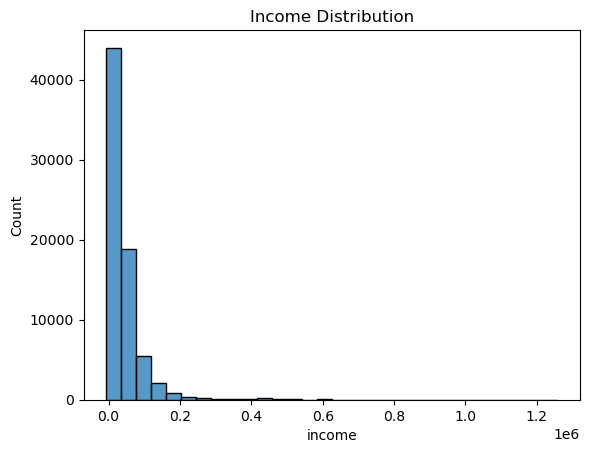

In [486]:
#2
sns.histplot(df['income'], bins=30)
plt.title('Income Distribution')
plt.show()


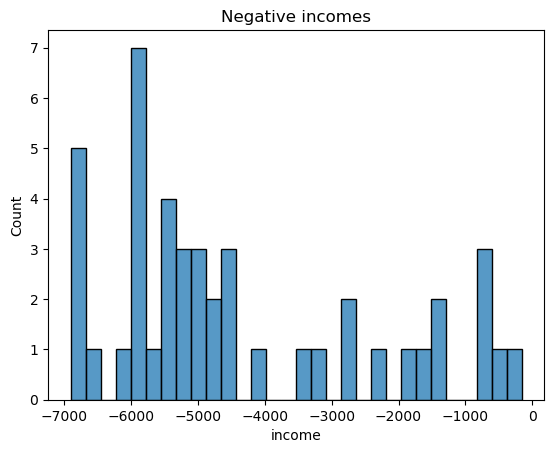

In [487]:
neg = df[df['income'] < 0]['income']
sns.histplot(neg, bins=30)
plt.title('Negative incomes')
plt.show()

In [488]:
#3
df.state_of_res.unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

<Axes: xlabel='age', ylabel='income'>

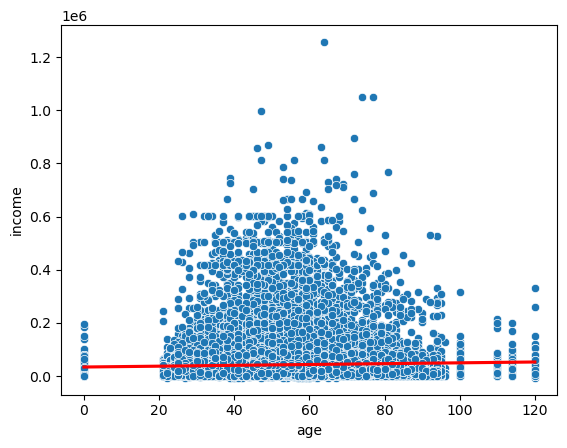

In [489]:
sns.scatterplot(df,x='age',y='income')
sns.regplot(df,x='age',y='income',color='red',scatter=False)

([0, 1, 2, 3],
 [Text(0, 0, 'Homeowner free and clear'),
  Text(1, 0, 'Rented'),
  Text(2, 0, 'Homeowner with mortgage/loan'),
  Text(3, 0, 'Occupied with no rent')])

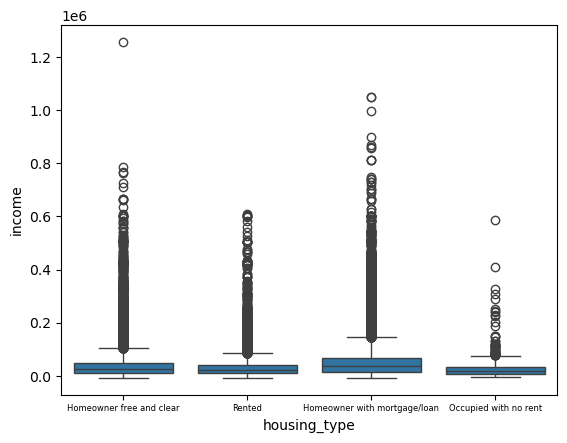

In [490]:
#4 
sns.boxplot(df,x='housing_type',y='income')
plt.xticks(fontsize=6)

<Axes: xlabel='marital_status', ylabel='income'>

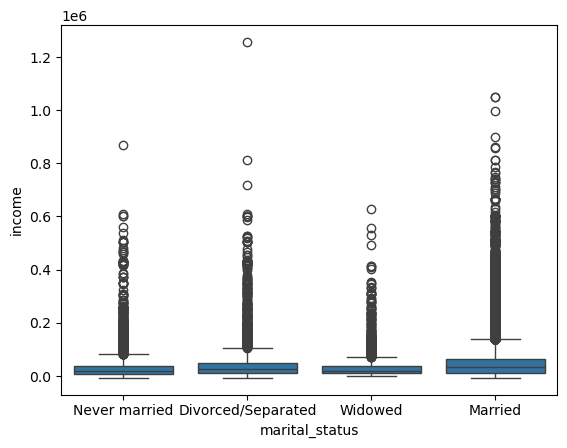

In [491]:
sns.boxplot(df,x='marital_status',y='income')

([0, 1, 2, 3],
 [Text(0, 0, 'Homeowner free and clear'),
  Text(1, 0, 'Rented'),
  Text(2, 0, 'Homeowner with mortgage/loan'),
  Text(3, 0, 'Occupied with no rent')])

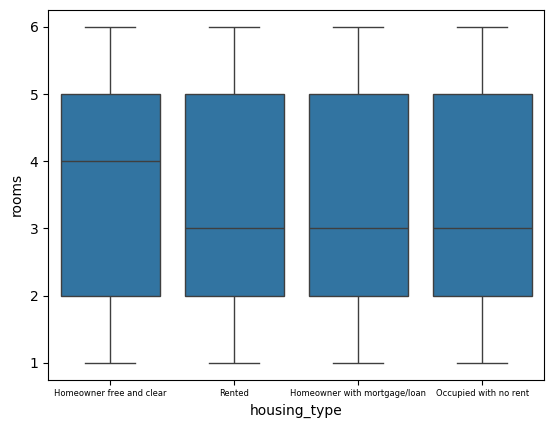

In [492]:
sns.boxplot(df,x='housing_type',y='rooms')
plt.xticks(fontsize=6)

<Axes: xlabel='gas_usage', ylabel='rooms'>

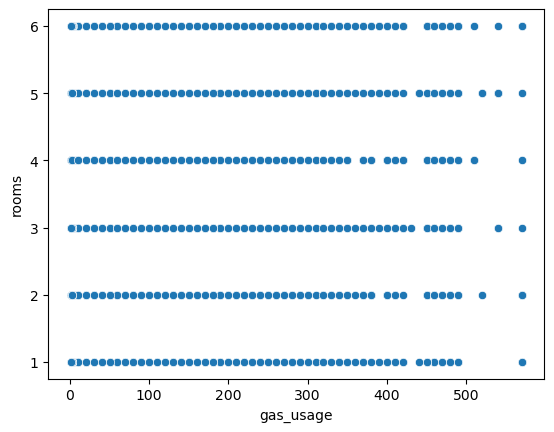

In [493]:
sns.scatterplot(df,x='gas_usage',y='rooms')

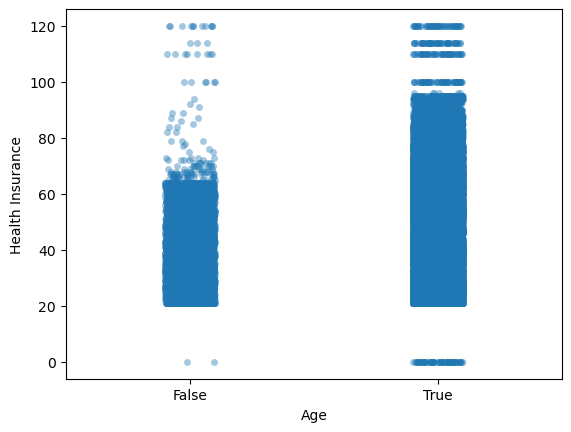

In [494]:
sns.stripplot(
    data=df,
    x='health_ins',
    y='age',
    jitter=True,
    alpha=0.4
)

plt.xlabel('Age')
plt.ylabel('Health Insurance')
plt.show()

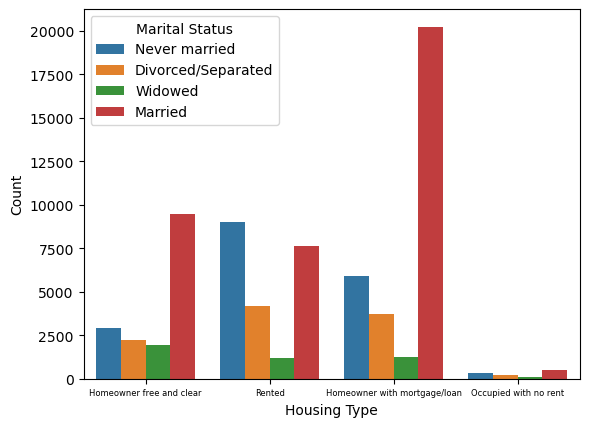

In [495]:
sns.countplot(
    data=df,
    x='housing_type',
    hue='marital_status'
)

plt.xlabel('Housing Type')
plt.xticks(fontsize=6)
plt.ylabel('Count')
plt.legend(title='Marital Status')
plt.show()

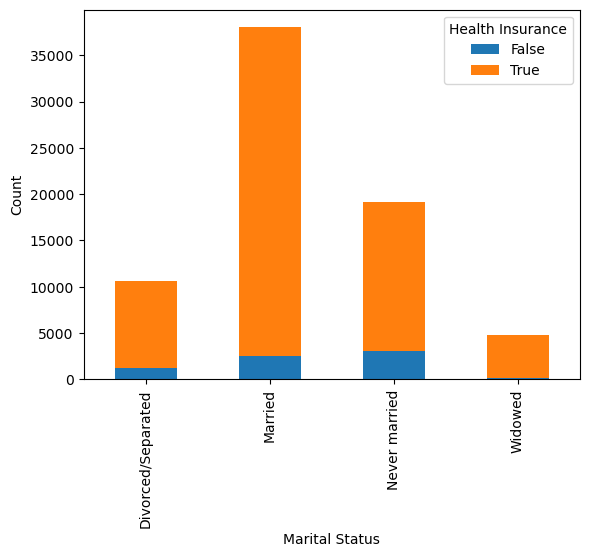

In [496]:
pd.crosstab(
    df['marital_status'],
    df['health_ins']
).plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Health Insurance')
plt.show()

<Axes: xlabel='age', ylabel='income'>

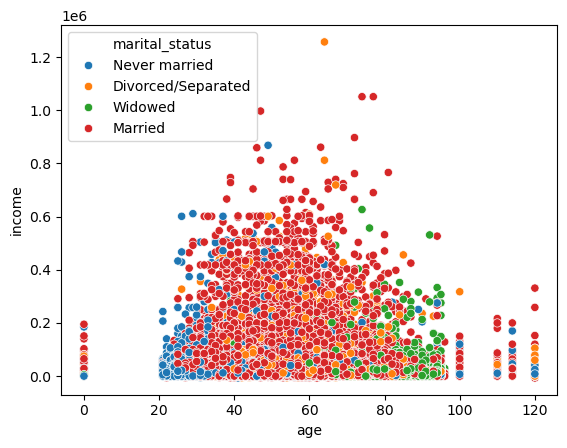

In [497]:
sns.scatterplot(df,x='age',y='income',hue='marital_status')

# Data Cleaning

In [498]:

df=df.rename(columns={'Unnamed: 0': 'idx'})
df.isnull().sum()

idx                   0
custid                0
sex                   0
is_employed       25515
income                0
marital_status        0
health_ins            0
housing_type       1686
num_vehicles       1686
age                   0
state_of_res          0
code_column           0
gas_usage          1686
rooms                 0
recent_move_b      1687
age_group             0
dtype: int64

##### We created 'niw' column with None values of is_employed column.

In [499]:
df['niw']=df['is_employed'].isna().astype(int) #New column with NaN values of is_employed
df['is_employed']=df['is_employed']==True #Replace NaN values to False values
df['sex']=(df['sex']=='Male').astype(int) #Replace False to 0 and True to 1 
df.head()

,idx,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b,age_group,niw
0,7,000006646_03,1,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F,Young,0
1,8,000007827_01,0,False,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T,Senior,1
2,9,000008359_04,0,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F,Middle-aged,0
3,10,000008529_01,0,False,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F,Senior,1
4,11,000008744_02,1,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F,Middle-aged,0


In [500]:
df['is_employed'] = df['is_employed'].astype(int)
df['health_ins'] = df['health_ins'].astype(int)
moda = df['recent_move_b'].mode()[0]
df['recent_move_b']=df['recent_move_b'].fillna( moda )
df['recent_move_b']=df['recent_move_b'].replace('F',0 )
df['recent_move_b']=df['recent_move_b'].replace('T',1 )

C:\Users\pufle\AppData\Local\Temp\ipykernel_34624\3494346374.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['recent_move_b']=df['recent_move_b'].replace('T',1 )


In [501]:
mediana = df['num_vehicles'].median()
df['num_vehicles']=df['num_vehicles'].fillna(mediana)
log_income =  np.sign(df['income']) * np.log1p(np.abs(df['income']))
df['income_norm'] = ((log_income - log_income.min()) / (log_income.max() - log_income.min()))


In [502]:
df = pd.get_dummies(df, columns=['housing_type','marital_status'], dtype=int)


In [503]:
df['age_norm'] = (

    (df['age'] - df['age'].min()) /
    (df['age'].max() - df['age'].min())
)

df['gas_usage']=df['gas_usage'].fillna(0)
df['gas_usage_norm'] = (

    (df['gas_usage'] - df['gas_usage'].min()) /
    (df['gas_usage'].max() - df['gas_usage'].min())
)
df['num_vehicles']=df['num_vehicles'].astype(int)


In [504]:
df=df.drop(columns=['age','gas_usage','custid','income','age_group','state_of_res'])

In [505]:
df.head()

,idx,sex,is_employed,health_ins,num_vehicles,code_column,rooms,recent_move_b,niw,income_norm,housing_type_Homeowner free and clear,housing_type_Homeowner with mortgage/loan,housing_type_Occupied with no rent,housing_type_Rented,marital_status_Divorced/Separated,marital_status_Married,marital_status_Never married,marital_status_Widowed,age_norm,gas_usage_norm
0,7,1,1,1,0,1047,3,0,0,0.823219,1,0,0,0,0,0,1,0,0.200000,0.368421
1,8,0,0,1,0,1047,6,1,1,0.825540,0,0,0,1,1,0,0,0,0.683333,0.005263
2,9,0,1,1,2,1047,3,0,0,0.821186,0,1,0,0,0,0,1,0,0.258333,0.070175
3,10,0,0,1,1,1047,2,0,1,0.846836,1,0,0,0,0,0,0,1,0.775000,0.210526
4,11,1,1,1,2,1047,2,0,0,0.848237,0,0,0,1,1,0,0,0,0.558333,0.005263


<Axes: >

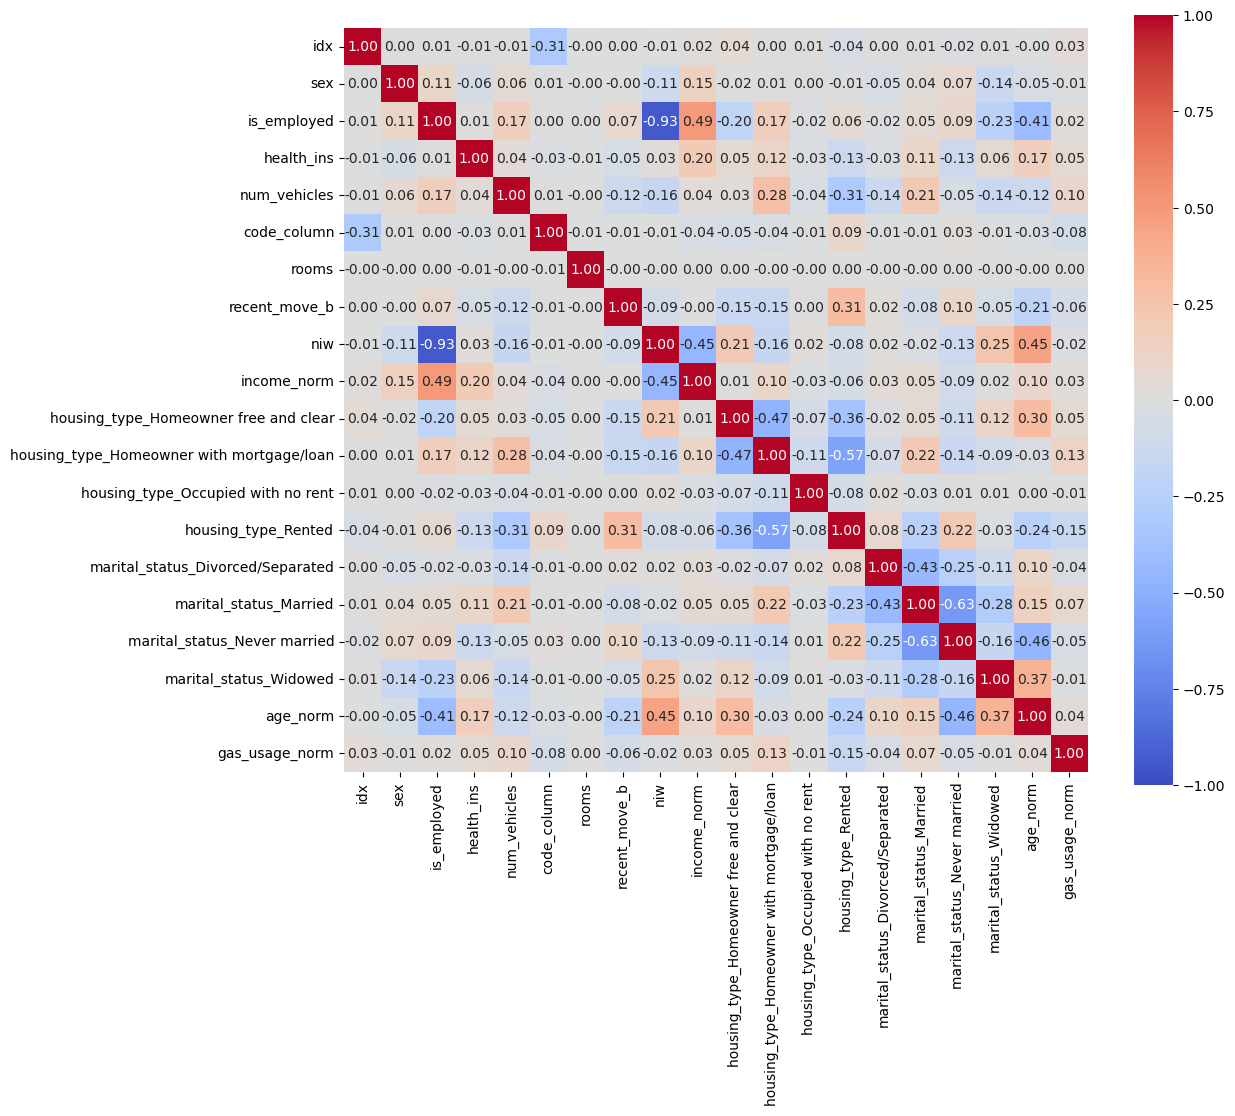

In [506]:
corr = df.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

# Model training


In [525]:

x = df.drop('health_ins', axis=1)
y = df['health_ins']

x_Tr, x_Vs, y_Tr, y_Vs = train_test_split( x, y,test_size=0.30,shuffle=True,random_state=24)

In [558]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=24),
    'Random Forest': RandomForestClassifier(random_state=24),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=15))
    ])
}
for name, model in models.items():
    
    # Cross Validation no training set
    scores = cross_val_score(
        model,
        x_Tr,
        y_Tr,
        cv=10,
        scoring='accuracy'
    )
    model.fit(x_Tr, y_Tr)
    
    y_pred = model.predict(x_Vs)
    
    # Validation score
    val_score = accuracy_score(y_Vs, y_pred)
    
    print(f'{name}')
    print(f'  CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}')
    print(f'  Validation accuracy: {val_score:.3f}')
    print()


c:\Users\pufle\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pufle\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression
  CV accuracy: 0.904 ± 0.001
  Validation accuracy: 0.906

Decision Tree
  CV accuracy: 0.845 ± 0.004
  Validation accuracy: 0.846

Random Forest
  CV accuracy: 0.904 ± 0.001
  Validation accuracy: 0.907

KNN
  CV accuracy: 0.904 ± 0.002
  Validation accuracy: 0.907



## Claramente o Random Forest e o Knn são as melhores opções!!!

<Axes: >

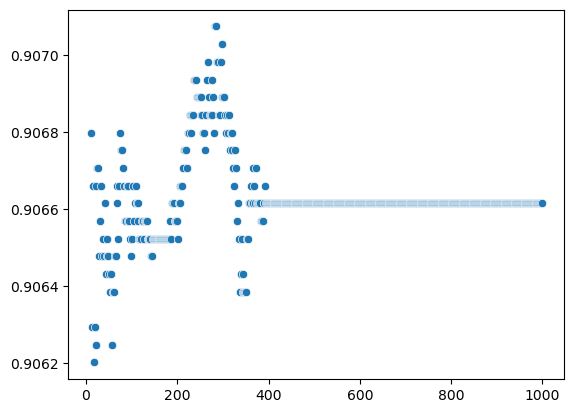

In [573]:
listx=[]
listy=[]
for k in range (11,1001,2):
    knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(x_Tr, y_Tr)
           
    y_pred = knn.predict(x_Vs)
        
        # Validation score
    val_score = accuracy_score(y_Vs, y_pred)
    listx.append(k)
    listy.append(val_score)
sns.scatterplot(x=listx,y=listy)
